

**Goal:** Classify email subject lines as SPAM or HAM using:
1. Text preprocessing and cleaning
2. Pseudo-labeling with pretrained transformer

# Install required packages


In [1]:
# Install required packages
!pip install pandas numpy nltk transformers torch tqdm matplotlib wordcloud kagglehub -q

# Download NLTK data


In [ ]:
# Download NLTK data
import nltk

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("averaged_perceptron_tagger")
nltk.download("omw-1.4")
nltk.download("punkt_tab")

print("✓ All dependencies installed successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✓ All dependencies installed successfully!


In [3]:
# =========================
# Standard Libraries
# =========================
import re
import logging
import warnings
from collections import Counter
from typing import Dict, List
from email.parser import Parser

# =========================
# Data Handling
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# =========================
# NLP
# =========================
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# =========================
# Deep Learning
# =========================
import torch
from transformers import pipeline
from tqdm import tqdm

# =========================
# Configuration
# =========================
warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# =========================
# Environment Check
# =========================
print("✓ All libraries imported successfully!")
print(f"✓ PyTorch GPU available: {torch.cuda.is_available()}")

✓ All libraries imported successfully!
✓ PyTorch GPU available: True


## Download the dataset

In [4]:
import os
email_dataset_path = '../data/raw/emails.csv'
if not os.path.exists(email_dataset_path):
    import kagglehub
    email_dataset_path = kagglehub.dataset_download('wcukierski/enron-email-dataset')

    print(os.listdir(email_dataset_path))

    email_dataset_path = os.path.join(email_dataset_path, 'emails.csv')
    print(email_dataset_path)

    print('Data source import complete.')
else :
    print('Dataset Path:', email_dataset_path)


Using Colab cache for faster access to the 'enron-email-dataset' dataset.
['emails.csv']
/kaggle/input/enron-email-dataset/emails.csv
Data source import complete.


---
## PART 1: LOAD DATASET
---

Download and load the Kaggle Enron Email Dataset.

**Dataset Info:**
- Shape: (517401, 2)
- Columns: ['file', 'message']
- Each row contains raw email message including headers and body

In [5]:
print("Loading dataset...")
try:
    data = pd.read_csv(email_dataset_path)
    print(f"Dataset Loaded Successfully")
except FileNotFoundError:
    print("Dataset not found. Download from: https://www.kaggle.com/datasets/wcukierski/enron-email-dataset")

Loading dataset...
Dataset Loaded Successfully


In [6]:
# Display basic info
print(f"\nDataset Shape: {data.shape}")
print(f"\nColumn Names: {data.columns.tolist()}")
print(f"\nMissing Values:")
print(data.isnull().sum())
print(f"\nDuplicate Rows: {data.duplicated().sum()}")


Dataset Shape: (517401, 2)

Column Names: ['file', 'message']

Missing Values:
file       0
message    0
dtype: int64

Duplicate Rows: 0


In [9]:
# Display sample rows
print("Sample Rows:")
print("\n" + "="*80)
for idx in range(min(2, len(data))):
    print(f"\nRow {idx}:")
    print(f"File: {data.iloc[idx]['file']}")
    print(f"Message (first 300 chars):\n{data.iloc[idx]['message']}...\n")
    print("="*80)

Sample Rows:


Row 0:
File: allen-p/_sent_mail/1.
Message (first 300 chars):
Message-ID: <18782981.1075855378110.JavaMail.evans@thyme>
Date: Mon, 14 May 2001 16:39:00 -0700 (PDT)
From: phillip.allen@enron.com
To: tim.belden@enron.com
Subject: 
Mime-Version: 1.0
Content-Type: text/plain; charset=us-ascii
Content-Transfer-Encoding: 7bit
X-From: Phillip K Allen
X-To: Tim Belden <Tim Belden/Enron@EnronXGate>
X-cc: 
X-bcc: 
X-Folder: \Phillip_Allen_Jan2002_1\Allen, Phillip K.\'Sent Mail
X-Origin: Allen-P
X-FileName: pallen (Non-Privileged).pst

Here is our forecast

 ...


Row 1:
File: allen-p/_sent_mail/10.
Message (first 300 chars):
Message-ID: <15464986.1075855378456.JavaMail.evans@thyme>
Date: Fri, 4 May 2001 13:51:00 -0700 (PDT)
From: phillip.allen@enron.com
To: john.lavorato@enron.com
Subject: Re:
Mime-Version: 1.0
Content-Type: text/plain; charset=us-ascii
Content-Transfer-Encoding: 7bit
X-From: Phillip K Allen
X-To: John J Lavorato <John J Lavorato/ENRON@enronXgate@ENRON>
X-cc: 
X-b

---
## PART 2: PARSE RAW EMAILS
---

Extract structured metadata from raw email messages.
Create columns for: message_id, date, from_email, to_email, subject, body, etc.

In [10]:
def parse_email_message(raw_message: str) -> Dict:
    """
    Parse a raw email message and extract key fields.
    """
    email_dict = {
        'subject': '',
        # 'message_id': '',
        # 'date': '',
        # 'from_email': '',
        # 'to_email': '',
        # 'cc': '',
        # 'bcc': '',
        # 'mime_version': '',
        # 'content_type': '',
        # 'content_transfer_encoding': '',
        # 'x_from': '',
        # 'x_to': '',
        # 'x_cc': '',
        # 'x_bcc': '',
        # 'x_folder': '',
        # 'x_origin': '',
        # 'x_filename': '',
        # 'body': ''
    }

    try:
        # Split headers from body
        if '\n\n' in raw_message:
            headers_part, body_part = raw_message.split('\n\n', 1)
        else:
            headers_part = raw_message
            body_part = ''

        # Parse headers
        parser = Parser()
        msg = parser.parsestr(headers_part)

        # Extract fields
        email_dict['subject'] = msg.get('Subject', '')
        # email_dict['message_id'] = msg.get('Message-ID', '')
        # email_dict['date'] = msg.get('Date', '')
        # email_dict['from_email'] = msg.get('From', '')
        # email_dict['to_email'] = msg.get('To', '')
        # email_dict['cc'] = msg.get('Cc', '')
        # email_dict['bcc'] = msg.get('Bcc', '')
        # email_dict['mime_version'] = msg.get('Mime-Version', '')
        # email_dict['content_type'] = msg.get('Content-Type', '')
        # email_dict['content_transfer_encoding'] = msg.get('Content-Transfer-Encoding', '')
        # email_dict['x_from'] = msg.get('X-From', '')
        # email_dict['x_to'] = msg.get('X-To', '')
        # email_dict['x_cc'] = msg.get('X-cc', '')
        # email_dict['x_bcc'] = msg.get('X-bcc', '')
        # email_dict['x_folder'] = msg.get('X-Folder', '')
        # email_dict['x_origin'] = msg.get('X-Origin', '')
        # email_dict['x_filename'] = msg.get('X-FileName', '')
        # email_dict['body'] = body_part.strip()

    except Exception as e:
        logger.warning(f"Error parsing email: {str(e)[:100]}")
        email_dict['body'] = raw_message

    return email_dict

print("✓ Email parsing function defined")

✓ Email parsing function defined


In [11]:
# Parse all emails
print(f"Parsing {len(data)} emails...")

parsed_emails = []
for idx, row in data.iterrows():
    if idx % 10000 == 0:  # type: ignore
        print(f"Parsed {idx} / {len(data)} emails")

    parsed = parse_email_message(row["message"])
    parsed["file"] = row["file"]
    parsed_emails.append(parsed)

# Create dataframe
columns_order = [
    "subject",
    # "file",
    # "message_id",
    # "date",
    # "from_email",
    # "to_email",
    # "cc",
    # "bcc",
    # "mime_version",
    # "content_type",
    # "content_transfer_encoding",
    # "x_from",
    # "x_to",
    # "x_cc",
    # "x_bcc",
    # "x_folder",
    # "x_origin",
    # "x_filename",
    # "body",
]

emails_df = pd.DataFrame(parsed_emails)
emails_df = emails_df[columns_order]

print(f"✓ Parsing complete!")
print(f"\nParsed Emails Shape: {emails_df.shape}")
print(f"\nColumns: {emails_df.columns.tolist()}")

Parsing 517401 emails...
Parsed 0 / 517401 emails
Parsed 10000 / 517401 emails
Parsed 20000 / 517401 emails
Parsed 30000 / 517401 emails
Parsed 40000 / 517401 emails
Parsed 50000 / 517401 emails
Parsed 60000 / 517401 emails
Parsed 70000 / 517401 emails
Parsed 80000 / 517401 emails
Parsed 90000 / 517401 emails
Parsed 100000 / 517401 emails
Parsed 110000 / 517401 emails
Parsed 120000 / 517401 emails
Parsed 130000 / 517401 emails
Parsed 140000 / 517401 emails
Parsed 150000 / 517401 emails
Parsed 160000 / 517401 emails
Parsed 170000 / 517401 emails
Parsed 180000 / 517401 emails
Parsed 190000 / 517401 emails
Parsed 200000 / 517401 emails
Parsed 210000 / 517401 emails
Parsed 220000 / 517401 emails
Parsed 230000 / 517401 emails
Parsed 240000 / 517401 emails
Parsed 250000 / 517401 emails
Parsed 260000 / 517401 emails
Parsed 270000 / 517401 emails
Parsed 280000 / 517401 emails
Parsed 290000 / 517401 emails
Parsed 300000 / 517401 emails
Parsed 310000 / 517401 emails
Parsed 320000 / 517401 emails

In [12]:
# Display parsed emails info
print(f"\nDataset Shape: {data.shape}")
print(f"\nColumn Names: {data.columns.tolist()}")

print(f"\nMissing Values per Column:")
print(emails_df.isnull().sum())

print(f"\nEmpty Subjects: {(emails_df['subject'] == '').sum() + emails_df['subject'].isnull().sum()}")
print(f"Duplicated Subjects: {emails_df['subject'].duplicated().sum()}")

print(f"\nSample Parsed Emails:")
print(emails_df[['subject']].head(10))


Dataset Shape: (517401, 2)

Column Names: ['file', 'message']

Missing Values per Column:
subject    0
dtype: int64

Empty Subjects: 19187
Duplicated Subjects: 358111

Sample Parsed Emails:
                                             subject
0                                                   
1                                                Re:
2                                           Re: test
3                                                   
4                                          Re: Hello
5                                          Re: Hello
6                                                   
7                       Re: PRC review - phone calls
8                     Re: High Speed Internet Access
9  FW: fixed forward or other Collar floor gas pr...


## Remove Duplicates and empty subjects

### Initial info

In [13]:
print(f"Initial shape: {emails_df.shape}")

# Display first rows
emails_df.head()

Initial shape: (517401, 1)


,subject
0,
1,Re:
2,Re: test
3,
4,Re: Hello


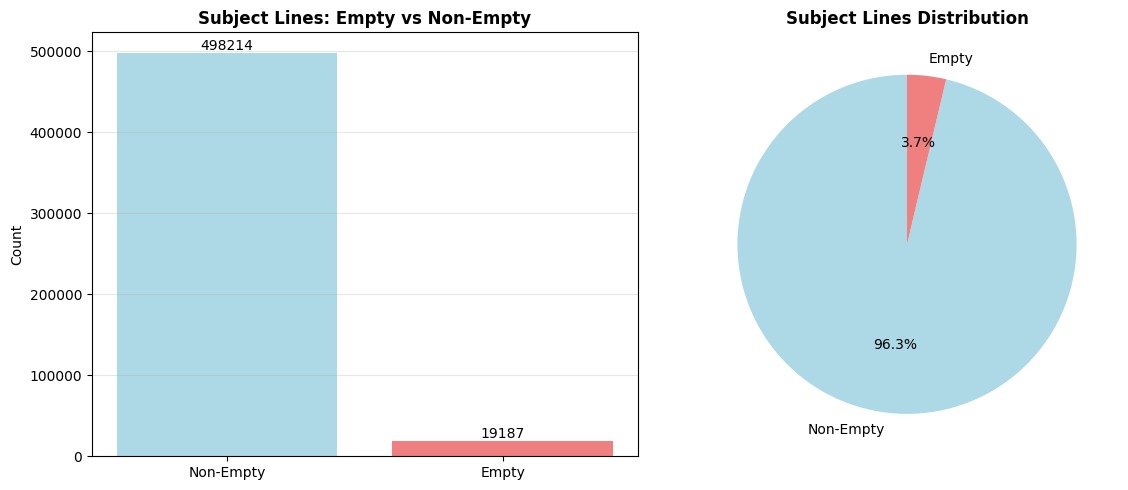

Non-empty subjects: 498214
Empty subjects: 19187


In [14]:
# Empty vs non-empty subjects
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

empty_count = (emails_df['subject'].isna().sum() + (emails_df['subject'] == '').sum())
non_empty_count = len(emails_df) - empty_count

# Bar chart
categories = ['Non-Empty', 'Empty']
counts = [non_empty_count, empty_count]
colors = ['lightblue', 'lightcoral']

ax1.bar(categories, counts, color=colors)
ax1.set_title('Subject Lines: Empty vs Non-Empty', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count')
for i, count in enumerate(counts):
    ax1.text(i, count, str(count), ha='center', va='bottom')
ax1.grid(axis='y', alpha=0.3)

# Pie chart
ax2.pie(counts, labels=categories, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Subject Lines Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Non-empty subjects: {non_empty_count}")
print(f"Empty subjects: {empty_count}")

### Remove empty subjects

In [15]:
# Count rows before cleaning
rows_before = len(emails_df)

# Detect empty subjects
empty_subject_mask = emails_df['subject'].str.strip() == ''

# Keep only non-empty subjects
emails_df = emails_df[~empty_subject_mask].copy()

# Count removed rows
removed_empty_subjects = rows_before - len(emails_df)

print(f"Removed {removed_empty_subjects} empty subject rows")
print(f"Current shape: {emails_df.shape}")

Removed 19187 empty subject rows
Current shape: (498214, 1)


### Remove duplicates

In [16]:
# Count rows before duplicate removal
rows_before = len(emails_df)

# Remove duplicate subjects
emails_df.drop_duplicates(subset=['subject'], inplace=True)

# Count removed duplicates
removed_duplicates = rows_before - len(emails_df)

print(f"Removed {removed_duplicates} duplicate subjects")
print(f"Current shape: {emails_df.shape}")

Removed 338925 duplicate subjects
Current shape: (159289, 1)


### Reset index

In [17]:
emails_df.reset_index(drop=True, inplace=True)

print("Index reset complete")
emails_df.head()

print(f"Final shape: {emails_df.shape}")

# Display sample subjects
print(emails_df[['subject']].head())

Index reset complete
Final shape: (159289, 1)
                          subject
0                             Re:
1                        Re: test
2                       Re: Hello
3    Re: PRC review - phone calls
4  Re: High Speed Internet Access


---
## PART 3: VISUALIZATION & DATA UNDERSTANDING
---

Create visualizations before pseudo-labeling.

No missing values to plot


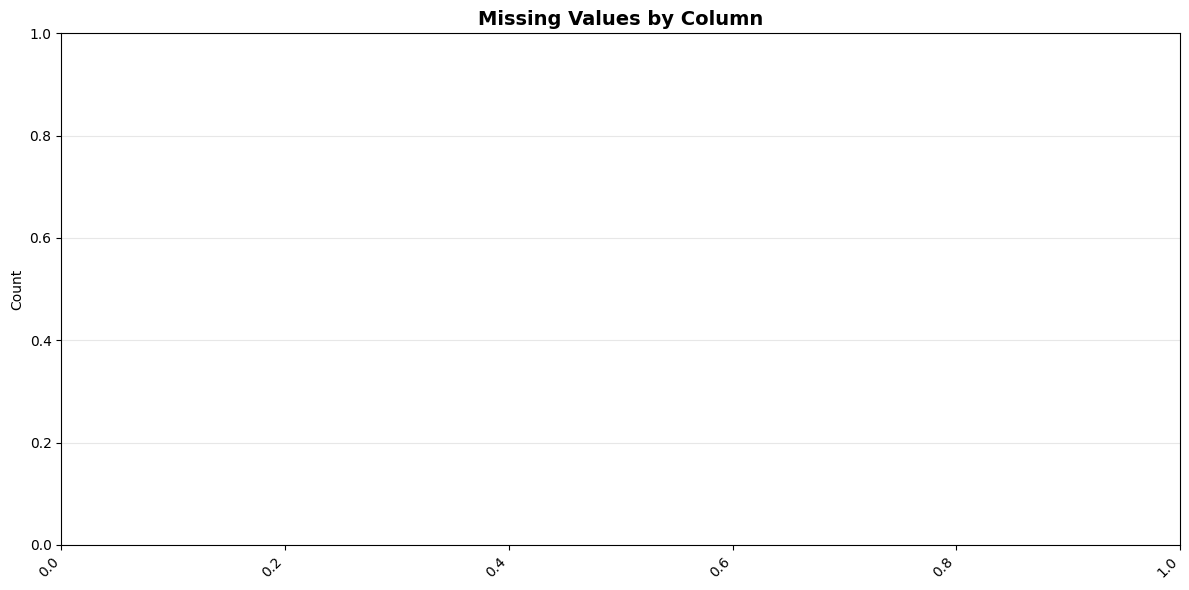

Missing values visualization complete


In [18]:
# Missing values visualization
fig, ax = plt.subplots(figsize=(12, 6))
missing = emails_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if not missing.empty:
    missing.plot(kind='bar', ax=ax, color='coral')
else:
    print("No missing values to plot")
ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Missing values visualization complete")

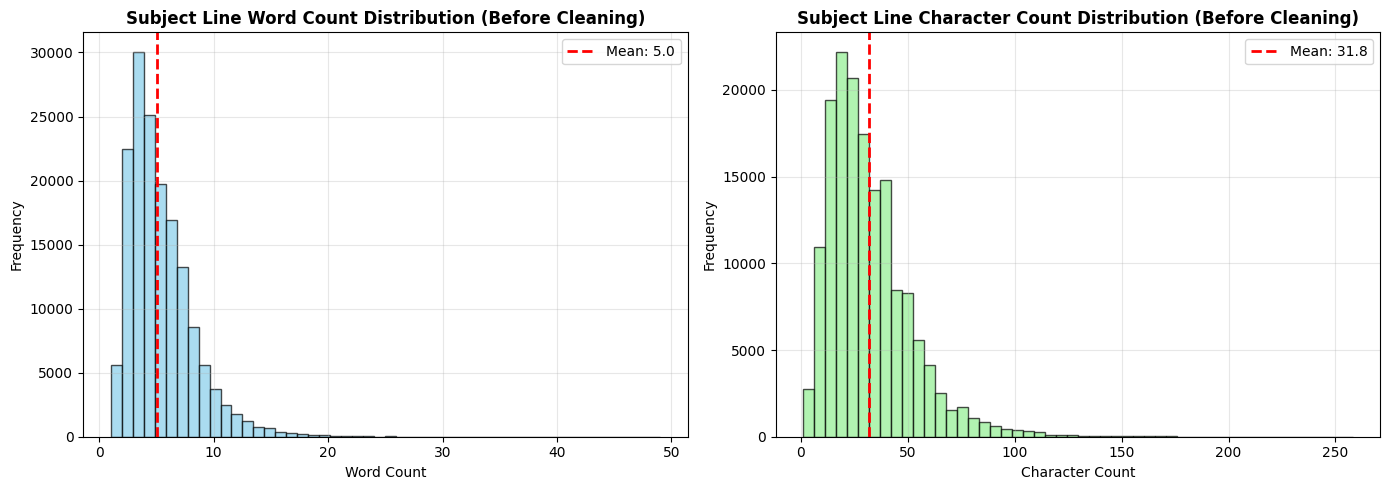

Average subject length: 5.0 words, 31.8 chars


In [19]:
# Subject length distribution
subject_lengths = [len(str(s).split()) if isinstance(s, str) else 0 for s in emails_df['subject']]
subject_chars = [len(str(s)) if isinstance(s, str) else 0 for s in emails_df['subject']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Word count
ax1.hist(subject_lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Word Count')
ax1.set_ylabel('Frequency')
ax1.set_title('Subject Line Word Count Distribution (Before Cleaning)', fontsize=12, fontweight='bold')
ax1.axvline(np.mean(subject_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(subject_lengths):.1f}')
ax1.legend()
ax1.grid(alpha=0.3)

# Character count
ax2.hist(subject_chars, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Character Count')
ax2.set_ylabel('Frequency')
ax2.set_title('Subject Line Character Count Distribution (Before Cleaning)', fontsize=12, fontweight='bold')
ax2.axvline(np.mean(subject_chars), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(subject_chars):.1f}')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average subject length: {np.mean(subject_lengths):.1f} words, {np.mean(subject_chars):.1f} chars")

---
## PART 4: TEXT PREPROCESSING
---

Clean and preprocess email subject lines.

Steps:
1. Lowercase
2. Remove URLs, emails, HTML
3. Remove punctuation and digits
4. Tokenize
5. Remove stopwords
6. Lemmatize

In [20]:
# Initialize preprocessing tools
STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()


def replace_numbers(match):
    num = match.group()

    # percentage
    if '%' in num:
        return ' percent '

    # money
    if '$' in num:
        return ' money '

    # extract digits only
    digits = re.sub(r'\D', '', num)
    if not digits:
        return ' number '

    value = int(digits)

    if value < 10:
        return ' smallnum '
    elif value < 100:
        return ' mediumnum '
    elif value < 1000:
        return ' bignum '
    else:
        return ' hugenum '

def clean_subject(text: str) -> str:
    """
    Clean and preprocess email subject text.
    """
    # Handle missing values
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ''

    text = text.strip()

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', ' url ', text, flags=re.MULTILINE)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' email ', text)

    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)

    # replace numbers
    text = re.sub(r'\$?\d[\d,]*(\.\d+)?%?', replace_numbers, text)

    # Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    tokens = [LEMMATIZER.lemmatize(token) for token in tokens
              if token not in STOP_WORDS and len(token) > 1]

    # Join back to string
    cleaned_text = ' '.join(tokens)

    return cleaned_text

print("✓ Cleaning function defined")

✓ Cleaning function defined


In [23]:

# Create preprocessing columns
print("Creating preprocessing columns...")

# Statistics before cleaning
emails_df['subject_char_len_before'] = emails_df['subject'].apply(lambda x: len(x) if isinstance(x, str) else 0)
emails_df['subject_word_count_before'] = emails_df['subject'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)

# Clean
print("Cleaning subjects...")
emails_df['subject_clean'] = emails_df['subject'].apply(clean_subject)

# Statistics after cleaning
emails_df['subject_char_len_after'] = emails_df['subject_clean'].apply(lambda x: len(x))
emails_df['subject_word_count_after'] = emails_df['subject_clean'].apply(lambda x: len(x.split()) if len(x) > 0 else 0)

print(f"✓ Preprocessing complete")

# Drop rows with empty cleaned subjects
initial_count = len(emails_df)
emails_df = emails_df[emails_df['subject_clean'].str.len() > 0].copy()
removed_count = initial_count - len(emails_df)

print(f"Removed {removed_count} rows with empty cleaned subjects")
print(f"Final shape: {emails_df.shape}")

emails_df = emails_df.reset_index(drop=True)

# Remove duplicate cleaned subjects
print("\nRemoving duplicate cleaned subjects...")
rows_before_dedup = len(emails_df)
emails_df.drop_duplicates(subset=['subject_clean'], inplace=True)
removed_duplicates = rows_before_dedup - len(emails_df)

print(f"Removed {removed_duplicates} duplicate cleaned subjects")
print(f"Final shape after deduplication: {emails_df.shape}")

emails_df = emails_df.reset_index(drop=True)


Creating preprocessing columns...
Cleaning subjects...
✓ Preprocessing complete
Removed 299 rows with empty cleaned subjects
Final shape: (158990, 6)

Removing duplicate cleaned subjects...
Removed 40020 duplicate cleaned subjects
Final shape after deduplication: (118970, 6)


In [24]:
# Display preprocessing statistics
print("Preprocessing Statistics:")
print(f"Total subjects: {len(emails_df)}")
print(f"\nBefore Cleaning:")
print(f"  Average characters: {emails_df['subject_char_len_before'].mean():.1f}")
print(f"  Average words: {emails_df['subject_word_count_before'].mean():.1f}")
print(f"\nAfter Cleaning:")
print(f"  Average characters: {emails_df['subject_char_len_after'].mean():.1f}")
print(f"  Average words: {emails_df['subject_word_count_after'].mean():.1f}")

# Show examples
print(f"\nExamples Before/After Cleaning:")
for idx in range(min(5, len(emails_df))):
    print(f"\nBefore: {emails_df.iloc[idx]['subject']}")
    print(f"After:  {emails_df.iloc[idx]['subject_clean']}")

Preprocessing Statistics:
Total subjects: 118970

Before Cleaning:
  Average characters: 33.0
  Average words: 5.2

After Cleaning:
  Average characters: 29.6
  Average words: 4.3

Examples Before/After Cleaning:

Before: Re: test
After:  test

Before: Re: Hello
After:  hello

Before: Re: PRC review - phone calls
After:  prc review phone call

Before: Re: High Speed Internet Access
After:  high speed internet access

Before: FW: fixed forward or other Collar floor gas price terms
After:  fw fixed forward collar floor gas price term


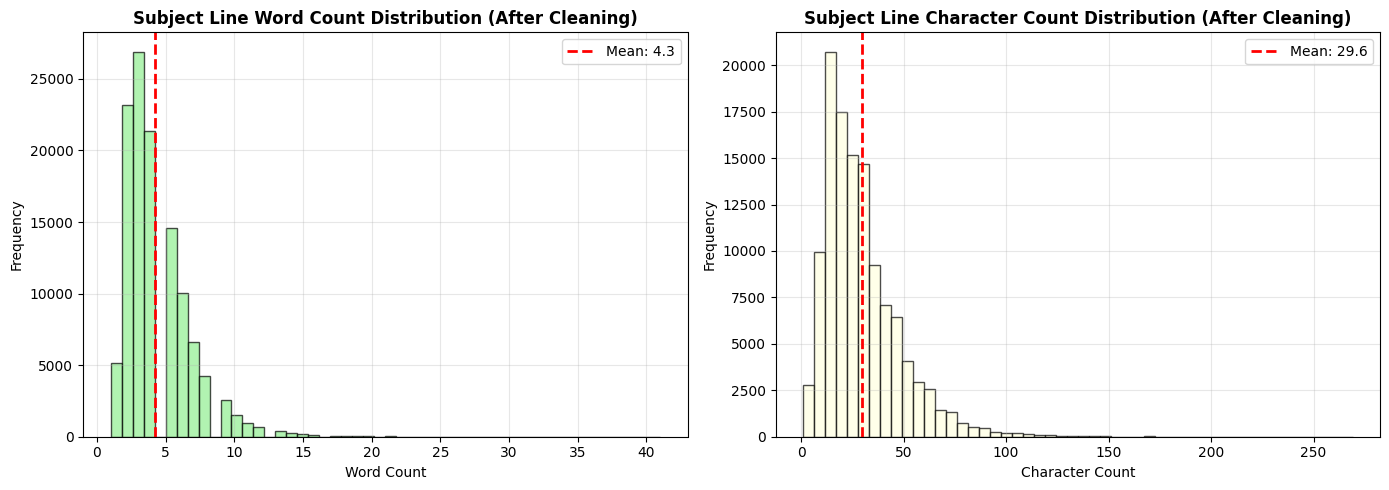

In [25]:
# Text length distribution after cleaning
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Word count after cleaning
ax1.hist(emails_df['subject_word_count_after'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Word Count')
ax1.set_ylabel('Frequency')
ax1.set_title('Subject Line Word Count Distribution (After Cleaning)', fontsize=12, fontweight='bold')
ax1.axvline(emails_df['subject_word_count_after'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {emails_df["subject_word_count_after"].mean():.1f}')
ax1.legend()
ax1.grid(alpha=0.3)

# Character count after cleaning
ax2.hist(emails_df['subject_char_len_after'], bins=50, color='lightyellow', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Character Count')
ax2.set_ylabel('Frequency')
ax2.set_title('Subject Line Character Count Distribution (After Cleaning)', fontsize=12, fontweight='bold')
ax2.axvline(emails_df['subject_char_len_after'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {emails_df["subject_char_len_after"].mean():.1f}')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

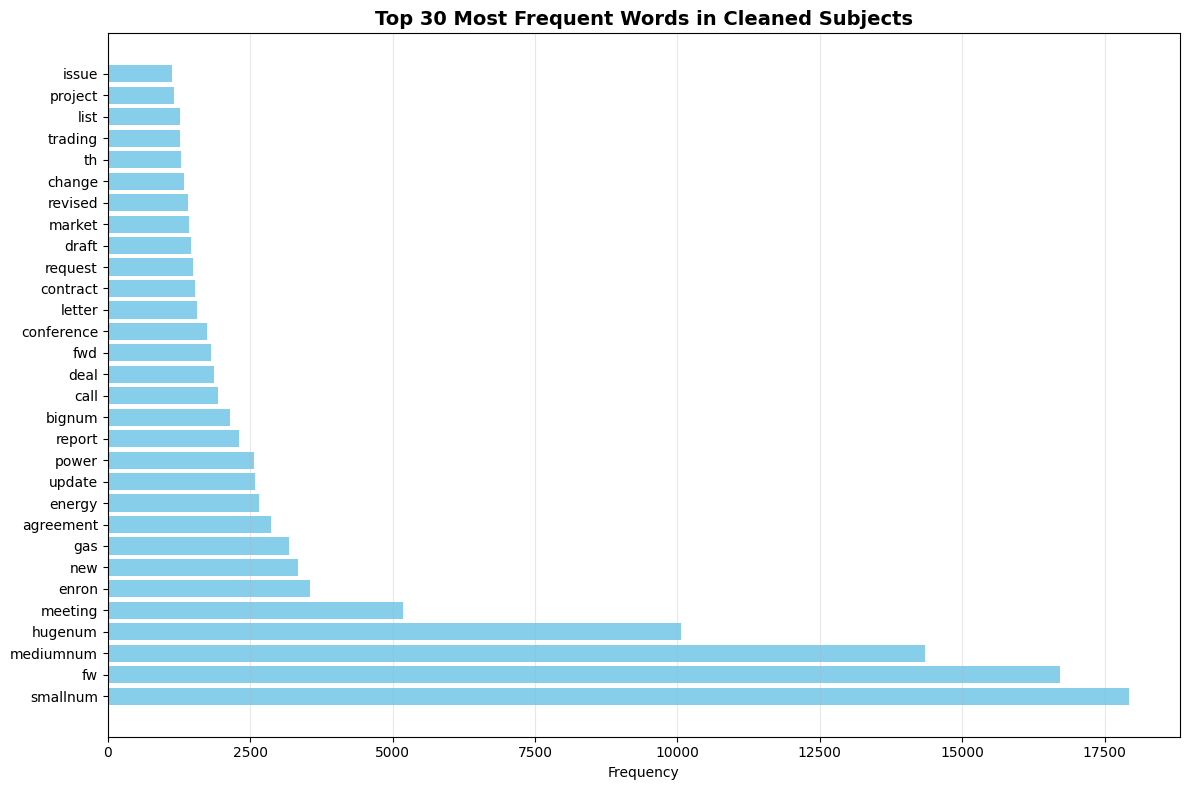

Most frequent words: ['smallnum', 'fw', 'mediumnum', 'hugenum', 'meeting', 'enron', 'new', 'gas', 'agreement', 'energy']


In [26]:
# Most frequent words after cleaning
all_words = ' '.join(emails_df['subject_clean']).split()
word_freq = Counter(all_words).most_common(30)

words = [word for word, count in word_freq]
counts = [count for word, count in word_freq]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(range(len(words)), counts, color='skyblue')
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)
ax.set_xlabel('Frequency')
ax.set_title('Top 30 Most Frequent Words in Cleaned Subjects', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Most frequent words: {words[:10]}")

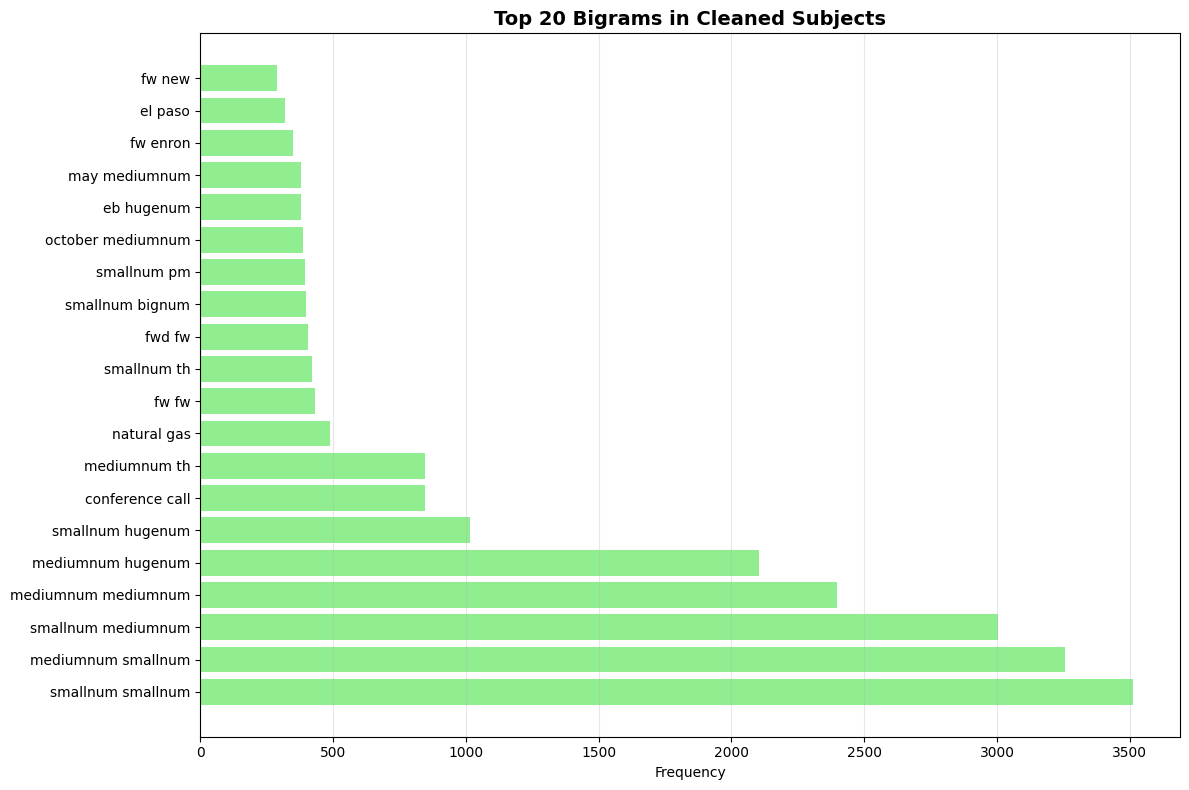

Top bigrams: ['smallnum smallnum', 'mediumnum smallnum', 'smallnum mediumnum', 'mediumnum mediumnum', 'mediumnum hugenum']


In [27]:
from nltk.util import ngrams
# Top bigrams
def get_top_ngrams(texts: list, n: int = 2, top_k: int = 20):
    all_ngrams = []
    for text in texts:
        words = str(text).split()
        text_ngrams = list(ngrams(words, n))
        all_ngrams.extend(text_ngrams)

    ngram_counts = Counter(all_ngrams)
    return ngram_counts.most_common(top_k)

# Bigrams
top_bigrams = get_top_ngrams(emails_df['subject_clean'], n=2, top_k=20)

bigram_labels = [' '.join(bg[0]) for bg in top_bigrams]
bigram_counts = [bg[1] for bg in top_bigrams]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(range(len(bigram_labels)), bigram_counts, color='lightgreen')
ax.set_yticks(range(len(bigram_labels)))
ax.set_yticklabels(bigram_labels)
ax.set_xlabel('Frequency')
ax.set_title('Top 20 Bigrams in Cleaned Subjects', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Top bigrams: {bigram_labels[:5]}")

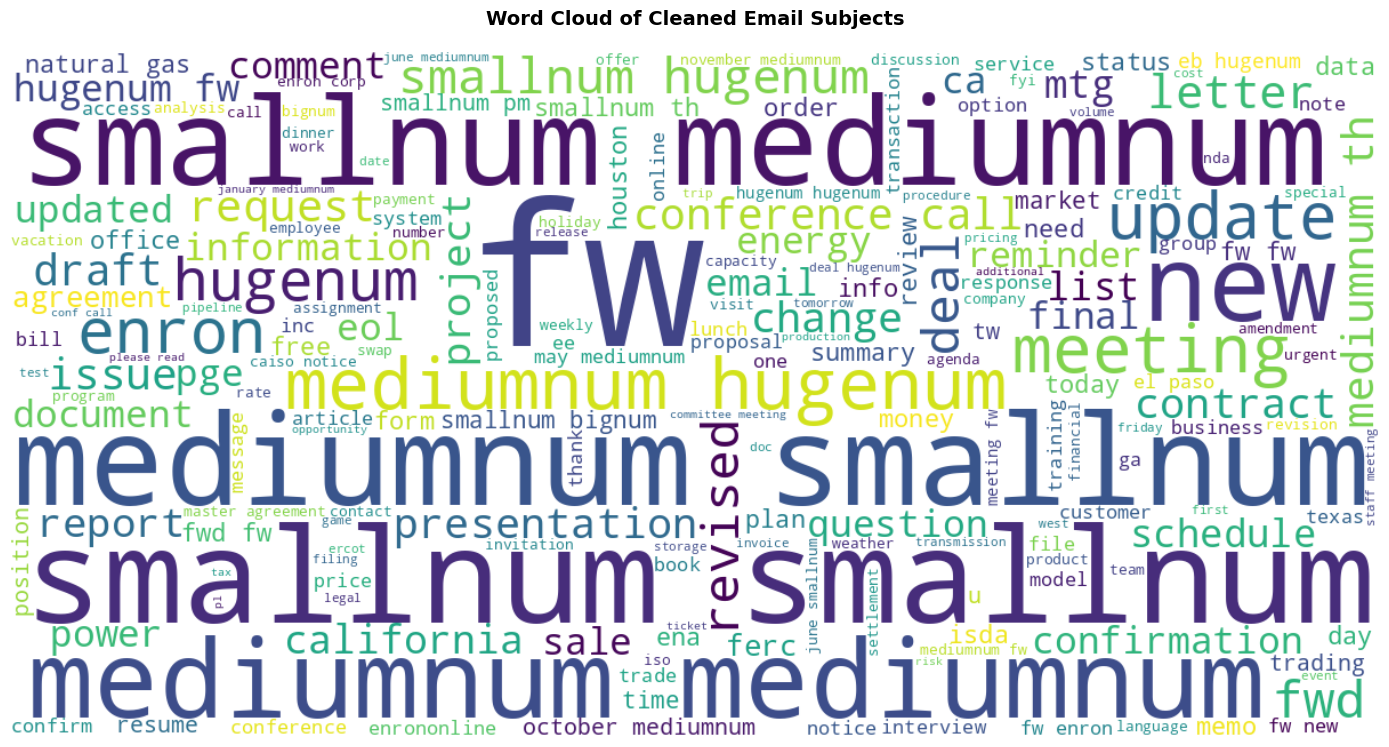

Word cloud created successfully


In [28]:
# Word cloud of cleaned subjects
fig, ax = plt.subplots(figsize=(14, 8))

all_subjects = ' '.join(emails_df['subject_clean'])
wordcloud = WordCloud(width=1200, height=600, background_color='white', colormap='viridis').generate(all_subjects)

ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud of Cleaned Email Subjects', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("Word cloud created successfully")

Save cleaned data

In [29]:
import os

folder_path = '../data/processed/'
file_name = 'emails_cleaned.csv'
full_path = os.path.join(folder_path, file_name)

os.makedirs(folder_path, exist_ok=True)

emails_df.to_csv(full_path, index=False, encoding='utf-8')

print(f"Saved successfully to: {full_path}")

Saved successfully to: ../data/processed/emails_cleaned.csv
